# Gaussian Splatting on  COLMAP dataset

This notebook trains a 3D Gaussian Splatting model on  COLMA format `temple` dataset (47 images + `sparse/0/{cameras,images,points3D}.bin`) using the original Inria implementation ([graphdeco-inria/gaussian-splatting](https://github.com/graphdeco-inria/gaussian-splatting)).

**Before you start:**
- `Runtime -> Change runtime type -> GPU` (T4 is fine,use older runime).
- Have `_colmap.zip` ready to upload when prompted in Step 2.

**Pipeline:**
 setup repo -> upload & arrange data -> undistort with COLMAP -> train -> render and evaluate -> export results (point cloud `.ply` + turntable video).

**Note:**
the `temple` COLMAP model uses a `SIMPLE_RADIAL` camera (it has lens distortion). The Inria training code only accepts undistorted `PINHOLE`or`SIMPLE_PINHOLE` cameras, so this notebook runs COLMAP's `image_undistorter` first,this is exactly what the repo's own `convert.py` does before training on any real world capture.

## 1. Check GPU and clone repo

In [1]:
!nvidia-smi

Thu Sep 10 05:25:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os

%cd /content
!rm -rf gaussian-splatting
!git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting.git
%cd gaussian-splatting

# check submodules pulled correctly
!ls submodules

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.72 MiB | 17.67 MiB/s, done.
Resolving deltas: 100% (593/593), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects:

## 2. Install dependencies

This installs PyTorch (CUDA build matching Colab's driver), then compiles the two custom CUDA extensions (`diff-gaussian-rasterization`, `simple-knn`).

In [3]:
# Colab already ships a CUDA-enabled torch; just confirm the version/toolkit match.
import torch
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available(), '| CUDA version:', torch.version.cuda)

torch 2.6.0+cu124 | CUDA available: True | CUDA version: 12.4


In [4]:
!pip install -q plyfile tqdm joblib

# Build the CUDA rasterizer + kNN modules against the notebook's torch/CUDA install
!pip install -q ./submodules/diff-gaussian-rasterization
!pip install -q ./submodules/simple-knn

# fused-ssim is used by newer versions of the repo's training loss; install if present
import os
if os.path.isdir('submodules/fused-ssim'):
    !pip install -q ./submodules/fused-ssim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


## 3. Upload and arrange the dataset

The training script expects this layout under a scene folder:
```
temple/
  images/          # the .png/.jpg source photos
  sparse/0/
    cameras.bin
    images.bin
    points3D.bin
```
(Option A) Run the next cell and pick the zip when the upload widget appears.

In [6]:
from google.colab import files
import zipfile, shutil, glob

%cd /content/gaussian-splatting

uploaded = files.upload()  # select temple_colmap.zip
zip_name = list(uploaded.keys())[0]

extract_dir = '/content/gaussian-splatting/data_raw'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(extract_dir)

print('Extracted contents:')
for root, dirs, fnames in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')

/content/gaussian-splatting


Saving temple_colmap.zip to temple_colmap.zip
Extracted contents:
data_raw/
  temple/
    sparse/
      0/
    images/


(Option B) Load from the drive

In [ ]:
# Option B: from Google Drive (uncomment)
# from google.colab import drive
# import zipfile
# drive.mount('/content/drive')
# with zipfile.ZipFile('/content/drive/MyDrive/gsplat/temple_colmap.zip') as z:
#     z.extractall('/content/gaussian-splatting/data_raw')
# !ls /content/gaussian-splatting/data_raw | wc -l

In [7]:
# Locate the actual scene folder (the one containing an `images/` dir and `sparse/0`)
# regardless of how deeply the zip nested it, then copy it into ./data/temple

scene_src = None
for root, dirs, fnames in os.walk(extract_dir):
    if 'images' in dirs and os.path.isdir(os.path.join(root, 'sparse', '0')):
        scene_src = root
        break

assert scene_src is not None, 'Could not find a folder with images/ and sparse/0/ - check the zip structure.'
print('Found scene at:', scene_src)

dataset_dir = '/content/gaussian-splatting/data/temple'
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)
shutil.copytree(scene_src, dataset_dir)

n_images = len(glob.glob(os.path.join(dataset_dir, 'images', '*')))
print(f'Dataset ready at {dataset_dir} with {n_images} images.')
!ls {dataset_dir}/sparse/0

Found scene at: /content/gaussian-splatting/data_raw/temple
Dataset ready at /content/gaussian-splatting/data/temple with 47 images.
cameras.bin  images.bin  points3D.bin


### (Optional) Preview a couple of source images

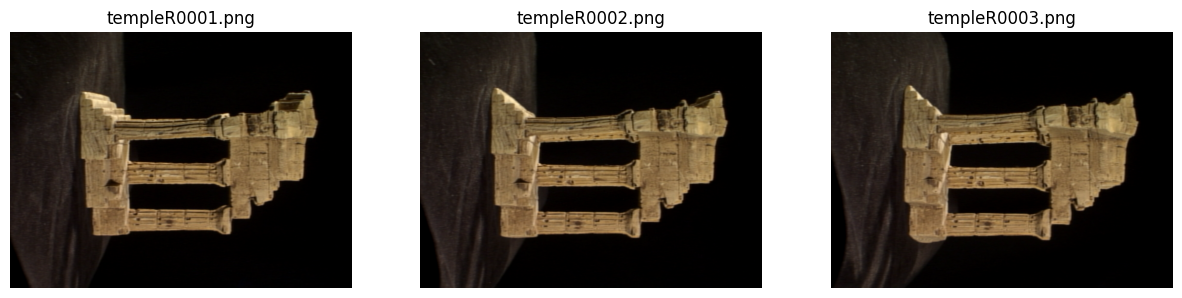

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

sample_imgs = sorted(glob.glob(os.path.join(dataset_dir, 'images', '*')))[:3]
fig, axes = plt.subplots(1, len(sample_imgs), figsize=(15, 5))
for ax, p in zip(axes, sample_imgs):
    ax.imshow(Image.open(p))
    ax.set_title(os.path.basename(p))
    ax.axis('off')
plt.show()

## 4. Undistort with COLMAP

Checks the camera model in `cameras.bin`. If it's already `PINHOLE`or`SIMPLE_PINHOLE` this is a no op; otherwise it installs COLMAP and runs `image_undistorter`, which reprojects the images to an ideal pinhole camera and writes a new `sparse/0` with the corrected (distortion free) intrinsics, the same thing `convert.py` does under the hood.

In [9]:
!pip install -q pycolmap
import pycolmap

rec = pycolmap.Reconstruction(os.path.join(dataset_dir, 'sparse', '0'))
cam = next(iter(rec.cameras.values()))
print('Camera model:', cam.model, '| params:', cam.params)

needs_undistort = cam.model.name not in ('PINHOLE', 'SIMPLE_PINHOLE')
print('Needs undistortion:', needs_undistort)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 35.0 MB/s eta 0:00:00
Camera model: CameraModelId.SIMPLE_RADIAL | params: [ 1.53956420e+03  3.20000000e+02  2.40000000e+02 -3.13216129e-01]
Needs undistortion: True


In [10]:
undistorted_dir = '/content/gaussian-splatting/data/temple_undistorted'

if needs_undistort:
    # Install COLMAP (CLI) - only needed for this undistortion step
    !apt-get -qq update && apt-get -qq install -y colmap > /dev/null
    !colmap -h | head -1

    if os.path.exists(undistorted_dir):
        shutil.rmtree(undistorted_dir)
    os.makedirs(undistorted_dir, exist_ok=True)

    !colmap image_undistorter \
        --image_path {dataset_dir}/images \
        --input_path {dataset_dir}/sparse/0 \
        --output_path {undistorted_dir} \
        --output_type COLMAP

    # image_undistorter writes sparse/*.bin directly (not sparse/0/) - match the
    # layout train.py expects, same as the repo's convert.py does
    os.makedirs(os.path.join(undistorted_dir, 'sparse', '0'), exist_ok=True)
    for fname in os.listdir(os.path.join(undistorted_dir, 'sparse')):
        if fname == '0':
            continue
        shutil.move(
            os.path.join(undistorted_dir, 'sparse', fname),
            os.path.join(undistorted_dir, 'sparse', '0', fname)
        )

    dataset_dir = undistorted_dir  # point everything downstream at the undistorted data

    rec2 = pycolmap.Reconstruction(os.path.join(dataset_dir, 'sparse', '0'))
    cam2 = next(iter(rec2.cameras.values()))
    print('New camera model:', cam2.model, '| params:', cam2.params)
else:
    print('Camera already undistorted - using original dataset_dir as-is.')

n_images = len(glob.glob(os.path.join(dataset_dir, 'images', '*')))
print(f'Training dataset: {dataset_dir} ({n_images} images)')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
COLMAP 3.7 -- Structure-from-Motion and Multi-View Stereo

Reading reconstruction

 => Reconstruction with 47 images and 3785 points

Image undistortion

Undistorting image [1/47]
Undistorting image [2/47]
Undistorting image [3/47]
Undistorting image [4/47]
Undistorting image [5/47]
Undistorting image [6/47]
Undistorting image [7/47]
Undistorting image [8/47]
Undistorting image [9/47]
Undistorting image [10/47]
Undistorting image [11/47]
Undistorting image [12/47]
Undistorting image [13/47]
Undistorting image [14/47]
Undistorting image [15/47]
Undistorting image [16/47]
Undistorting image [17/47]
Undistorting image [18/47]
Undistorting image [19/47]
Undistorting image [20/47]
Undistorting image [21/47]
Undistorting image [22/47]
Undistorting image [23/47]
Undi

## 5. Train

Default settings run 30,000 iterations, which is the paper's setting is for more than a small 47 image object scan scene like this needs. For a first pass, `--iterations 7000` gives a good preview in a few minutes on a T4; then upscale `30000` for a final high quality result.

`--eval` holds out every 8th image (COLMAP convention in this repo) to report hold out PSNR/SSIM/LPIPS.

In [16]:
ITERATIONS = 30000  # increase to 30000 for a final quality run
MODEL_DIR = '/content/gaussian-splatting/output/temple'

!python train.py \
  -s {dataset_dir} \
  -m {MODEL_DIR} \
  --eval \
  --iterations {ITERATIONS} \
  --test_iterations {ITERATIONS} \
  --save_iterations {ITERATIONS}

2026-09-10 05:44:14.603582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789019054.625680    6936 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789019054.631633    6936 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-10 05:44:14.651433: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing /content/gaussian-splatting/output/temple
Output folder: /content/gaussian-splatting/output/temple [10/09 

## 6. Evaluate hold out views

Renders the test split cameras and computes standard novel-view-synthesis metrics.

In [17]:
!python render.py -m {MODEL_DIR}
!python metrics.py -m {MODEL_DIR}

Looking for config file in /content/gaussian-splatting/output/temple/cfg_args
Config file found: /content/gaussian-splatting/output/temple/cfg_args
Rendering /content/gaussian-splatting/output/temple
Loading trained model at iteration 30000 [10/09 06:06:15]
------------LLFF HOLD------------- [10/09 06:06:15]
Reading camera 47/47 [10/09 06:06:15]
Loading Training Cameras [10/09 06:06:15]
Loading Test Cameras [10/09 06:06:16]
Rendering progress: 100% 41/41 [00:07<00:00,  5.31it/s]
Rendering progress: 100% 6/6 [00:01<00:00,  5.58it/s]

Scene: /content/gaussian-splatting/output/temple
Method: ours_7000
Metric evaluation progress: 100% 6/6 [00:09<00:00,  1.64s/it]
  SSIM :    0.8412991
  PSNR :   24.8658524
  LPIPS:    0.1704560

Method: ours_30000
Metric evaluation progress: 100% 6/6 [00:10<00:00,  1.68s/it]
  SSIM :    0.8128762
  PSNR :   24.9585495
  LPIPS:    0.1787328



## 7. Look at some rendered vs. ground truth frames

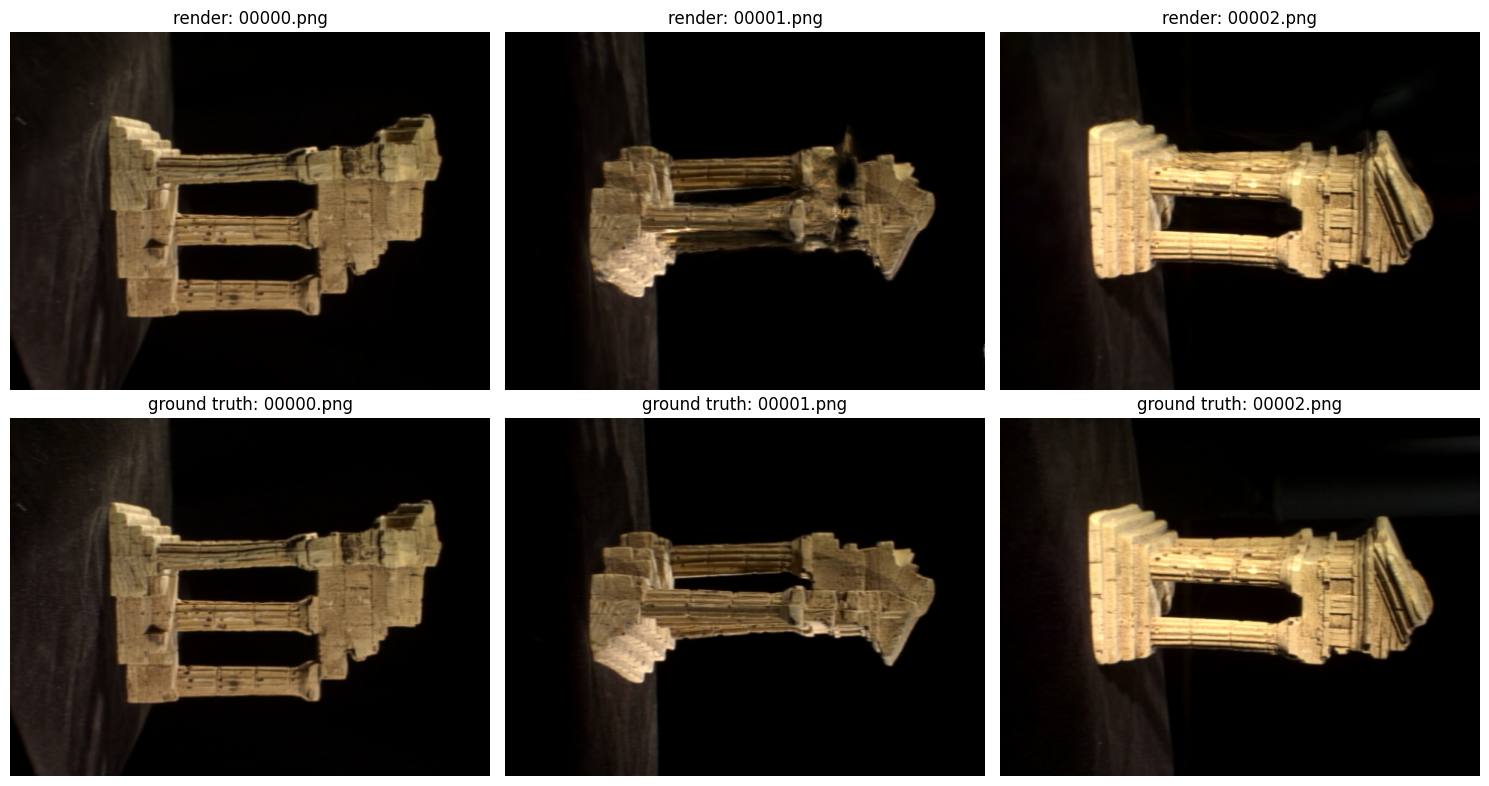

In [18]:
render_dir = os.path.join(MODEL_DIR, 'test', f'ours_{ITERATIONS}', 'renders')
gt_dir = os.path.join(MODEL_DIR, 'test', f'ours_{ITERATIONS}', 'gt')

renders = sorted(glob.glob(os.path.join(render_dir, '*')))[:3]
fig, axes = plt.subplots(2, len(renders), figsize=(15, 8))
for i, r in enumerate(renders):
    name = os.path.basename(r)
    axes[0, i].imshow(Image.open(r)); axes[0, i].set_title(f'render: {name}'); axes[0, i].axis('off')
    gt_path = os.path.join(gt_dir, name)
    axes[1, i].imshow(Image.open(gt_path)); axes[1, i].set_title(f'ground truth: {name}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

## 8. Export results

- `point_cloud.ply`: the trained Gaussian splat scene. Open it in a splat viewer such as [antimatter15/splat](https://antimatter15.com/splat/)  or [SuperSplat](https://playcanvas.com/supersplat/editor).
- A zipped copy of the full output folder (checkpoints + renders + logs), for download or for copying to Drive.

In [19]:
ply_path = os.path.join(MODEL_DIR, 'point_cloud', f'iteration_{ITERATIONS}', 'point_cloud.ply')
print('PLY at:', ply_path, '- exists:', os.path.exists(ply_path))

files.download(ply_path)

PLY at: /content/gaussian-splatting/output/temple/point_cloud/iteration_30000/point_cloud.ply - exists: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Optional: zip the whole output dir and download it, or save straight to Google Drive

!zip -r -q /content/temple_gaussian_output.zip {MODEL_DIR}
files.download('/content/temple_gaussian_output.zip')

# --- To save to Drive instead of downloading locally, uncomment: ---
# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/temple_gaussian_output.zip /content/drive/MyDrive/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes / troubleshooting

- **`Colmap camera model not handled` error**: this means training was pointed at a distorted (`SIMPLE_RADIAL`/`RADIAL`/`OPENCV`, etc.) camera model. Step 3b handles this automatically by running COLMAP's `image_undistorter`; if `apt-get install colmap` fails in your Colab environment, you can instead undistort locally and re-upload the already-undistorted `sparse/0` + `images`.
- **CUDA build errors in Step 2**: Colab's pre-installed torch/CUDA versions can drift. If `pip install ./submodules/...` fails to compile, check `torch.version.cuda` from the earlier cell and, if needed, reinstall a matching torch first (see the repo's README for the exact `--index-url` for your CUDA version), then re-run the submodule installs.
- **47 images is a small scene**: this is a great test case, but the reconstruction can look sparse/thin at edges the cameras didn't cover well. If quality is limited, consider running COLMAP's dense stereo mode beforehand, or capturing more views.
- **`--eval` test split**: the repo's default heldout logic takes every 8th image sorted by name; with only 47 images that's ~6 test images, so metric numbers will be noisy - useful for sanity-checking, not for a paper-grade benchmark.
- **Runtime**: `7000` iterations on a Colab T4 for a scene this size is typically a few minutes; `30000` iterations (paper default) is roughly 4-6x longer.
- **Viewing interactively**: the original repo also ships a real-time SIBR viewer, but it needs a desktop OS/X-server and won't run in Colab - use a web viewer (linked above) for interactive inspection instead.